In [5]:
import numpy as np
import matplotlib.pyplot as plt
mu=5
sig=1

In [11]:
# part A



itera=5000
x_o=0
burn=int(0.2*itera)
def tar(x):
    return np.exp(-(x-mu)**2/(2*sig**2))
samples=np.zeros(itera)
x=x_o 
for i in range(itera):
    prop=x+np.random.normal(0,1)
    alpha=tar(prop)/tar(x)
    acceptance_prop=min(1,alpha)   
    if np.random.rand()<acceptance_prop:
        x=prop
    samples[i]=x
post_burn_sample=samples[burn :]
emp_mean=np.mean(post_burn_sample)
emp_std=np.std(post_burn_sample)
print(emp_mean," ", mu)
print(emp_std," ",sig)        


5.025468588425727   5
0.9706806395644719   1


Text(0, 0.5, 'x')

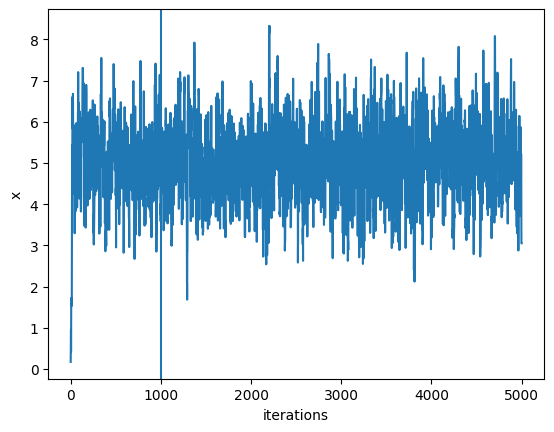

In [13]:
# part B
# trace plot
plt.plot(samples)
plt.axvline(burn)
plt.xlabel("iterations")
plt.ylabel("x")



Text(0, 0.5, 'Density')

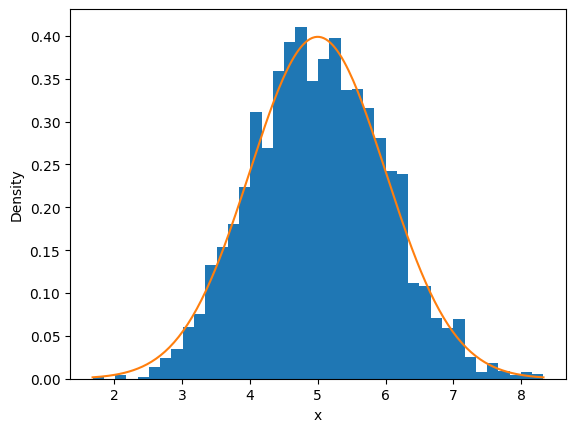

In [18]:
x_vals = np.linspace(min(post_burn_sample),
                     max(post_burn_sample), 200)
true_pdf = (1 / (np.sqrt(2*np.pi)*sig)) * \
           np.exp(-((x_vals - mu)**2) / (2*sig**2))
plt.hist(post_burn_sample, bins=40, density=True)
plt.plot(x_vals, true_pdf)
plt.xlabel("x")
plt.ylabel("Density")

# Q2

In [19]:
import numpy as np
import matplotlib.pyplot as plt
lam=0.5
itera=5000
x_o=1.0
burn=int(0.2*itera)


In [37]:
# part A
def tar(x):
    if x<=0:
        return 0
    return lam*np.exp(-lam*x)    
samples=np.zeros(itera)
x=x_o 
accepted=0
for i in range(itera):
    y=np.random.exponential(scale=1.0)
    if np.random.rand()<0.5:
        prop=x+y
    else :
        prop=x-y    
    
    if prop<=0:
        samples[i]=x
        continue
    target_ratio=tar(prop)/tar(x)
    
    alpha=min(1,target_ratio)
    if np.random.rand()<alpha:
        x=prop
        accepted+=1
    samples[i]=x
accepted_ratio=accepted/itera
print("acceptance ratio" ,accepted_ratio) 
post_burn_sample=samples[burn :]
emp_mean=np.mean(post_burn_sample)
print("emp_mean : ",emp_mean)   
print("true mean : ", 1/lam)       

acceptance ratio 0.6586
emp_mean :  2.011083048196335
true mean :  2.0


Text(0, 0.5, 'x')

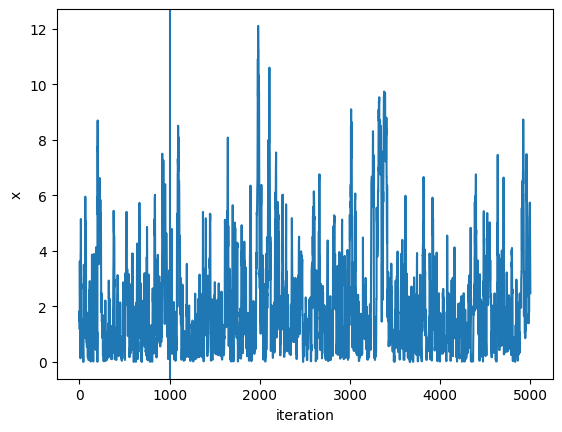

In [38]:
# part B
# trace plot
plt.plot(samples)
plt.axvline(burn)
plt.xlabel("iteration")
plt.ylabel("x")

Text(0, 0.5, 'density')

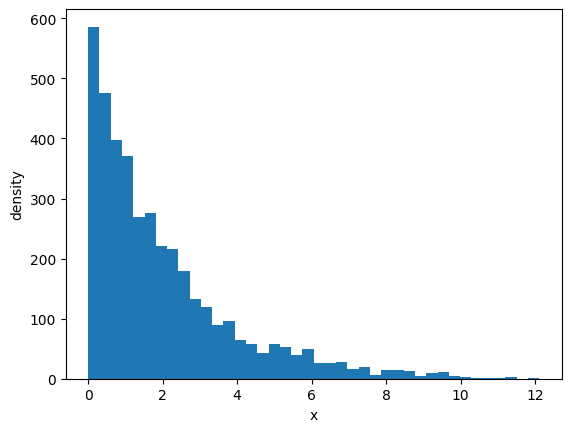

In [40]:
# histogram
x_vals=np.linspace(0,np.max(post_burn_sample),200)
true_pdf=lam*np.exp(-lam*x_vals)
plt.hist(post_burn_sample,bins=40)
plt.xlabel("x")
plt.ylabel("density")

the proposal distubution is asymmetric so the metropolis-hashing acceptance probability must include the proposal ratio q(xt|x') to maintain detalied balance.without this correction,the sampler becomes biased and doesnt not converge to the correct exponential target distrubution

# Q3

In [42]:
# part A
import numpy as np
import matplotlib.pyplot as plt
p_true=0.6
n_trials=100
heads=np.random.binomial(n_trials,p_true)
tails=n_trials-heads
print("heads: ",heads)
print("Tails: ",tails)

heads:  69
Tails:  31


In [45]:
def log_posterier(p):
    if p<=0 or p>=1:
        return -np.inf
    return heads*np.log(p)+tails*np.log(1-p)
n_iter=1000
burn=int(0.2*n_iter)
proposal_std=0.1
samples=np.zeros(n_iter)
p=0.5
accepted=0
for i in range(n_iter):
    proposal=p+np.random.normal(0,proposal_std)
    if proposal<=0 or proposal>=1:
        samples[i]=p
        continue
    log_alpha=log_posterier(proposal)-log_posterier(p)
    alpha=min(1,np.exp(log_alpha))
    if np.random.rand()<alpha:
        p=proposal
        accepted+=1
    samples[i]=p
accepted_ratio=accepted/n_iter
print("acceptance ratio: ",accepted_ratio)
post_samples=samples[burn :]
post_mean=np.mean(post_samples)
lower=np.percentile(post_samples,2.5)
upper=np.percentile(post_samples,97.5)
print("posterier mean :",post_mean)
print("95% credible interval: ",(lower,upper))  
print("true p: ",p_true)      

acceptance ratio:  0.501
posterier mean : 0.6878503860101165
95% credible interval:  (0.5973188816021507, 0.7773276330909331)
true p:  0.6


Text(0, 0.5, 'density')

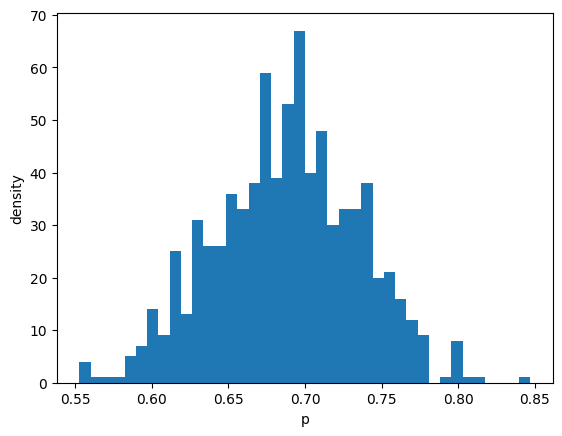

In [46]:
# part B
plt.hist(post_samples,bins=40)
plt.xlabel("p")
plt.ylabel("density")

posterior mean is very close to the true bias and the 95% credible interval contains the true value.this shows that th metropolis algorithm successfully recovered the underlying coin bias from the observed data